<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a 

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [42]:
# Библиотеки
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV


In [22]:
df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
df.sort_index(inplace=True)
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [24]:
df.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


Данные состоят из разбивки по 10 минут и количества заказов. 

## Анализ

<AxesSubplot:xlabel='datetime'>

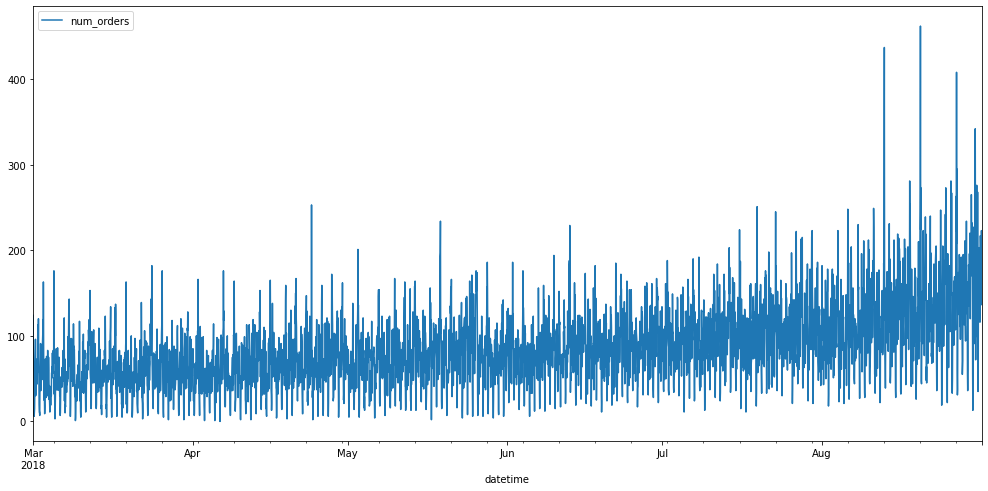

In [25]:
# ресемплирование по одному часу
df = df.resample('1H').sum()
figsize = (17,8)
df.plot(figsize=figsize)

<AxesSubplot:xlabel='datetime'>

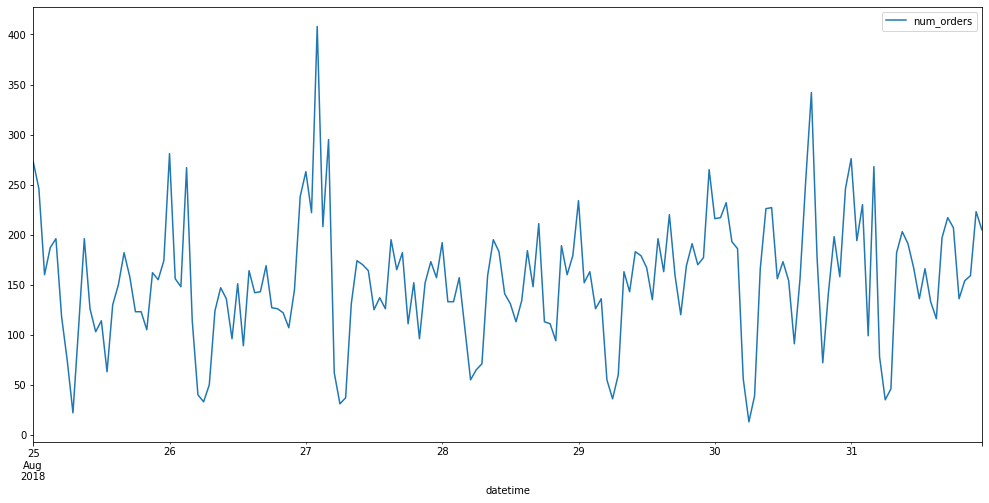

In [26]:
# Посмотрим на последнюю неделю 
df['2018-08-25':'2018-08-31'].plot(figsize=figsize)

<AxesSubplot:xlabel='datetime'>

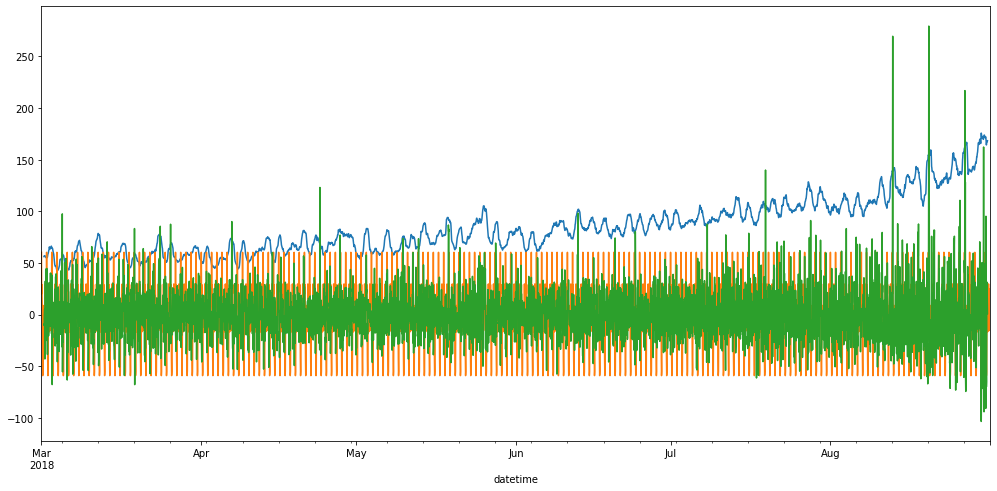

In [27]:
# проанализируем тренды
decomposed_df = seasonal_decompose(df)
decomposed_df.trend.plot(figsize=figsize)
decomposed_df.seasonal.plot(figsize=figsize)
decomposed_df.resid.plot(figsize=figsize)

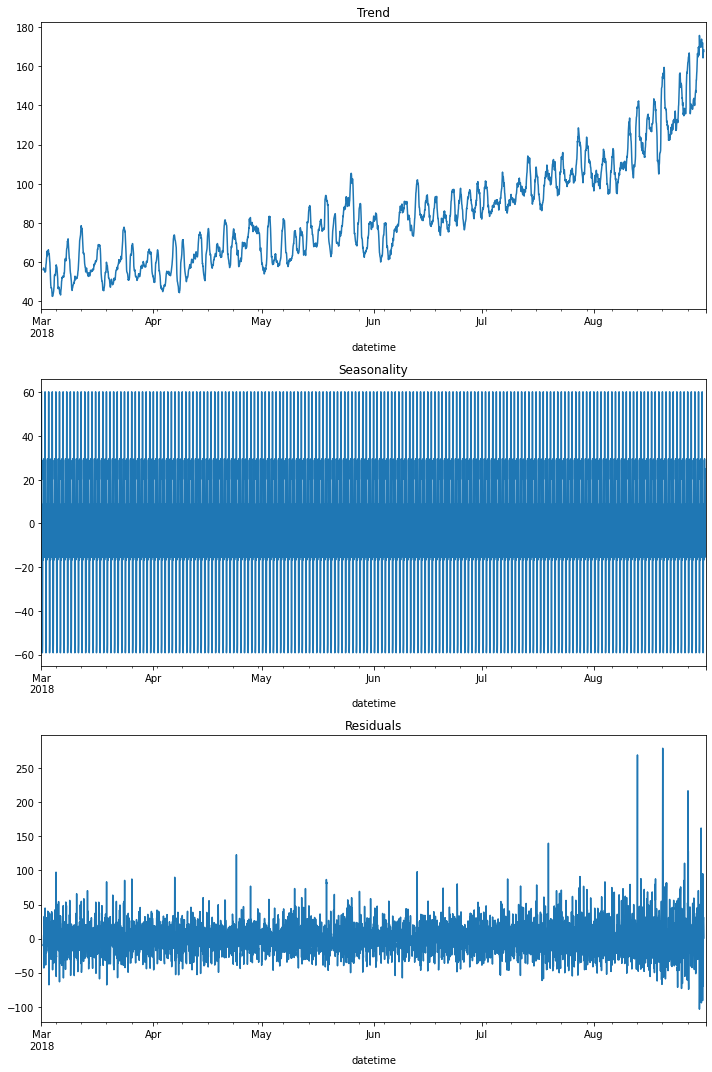

In [28]:
decomposed = seasonal_decompose(df)

plt.figure(figsize=(10, 15))
plt.subplot(311)

decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)

decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)

decomposed.resid.plot(ax=plt.gca()) 
plt.title('Residuals')
plt.tight_layout()

<AxesSubplot:xlabel='datetime'>

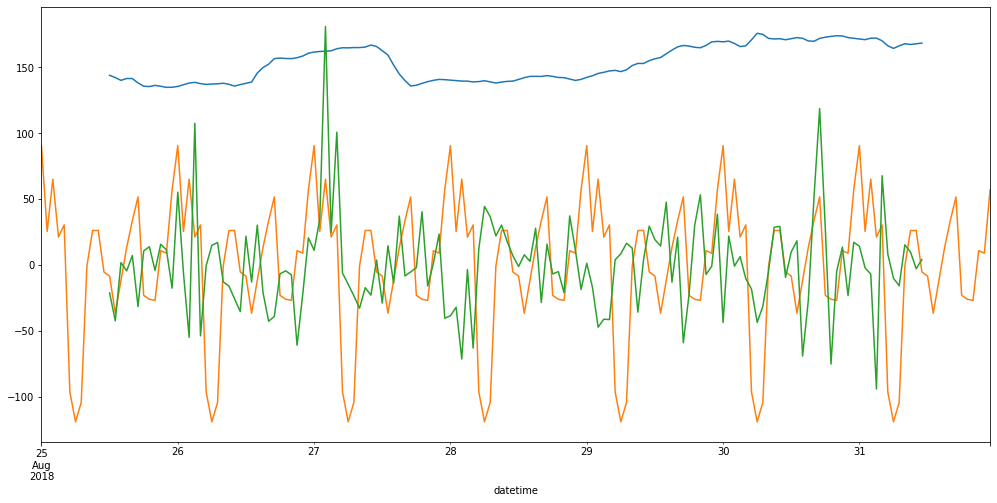

In [29]:
# тренды для последней недели
decomposed_df = seasonal_decompose(df['2018-08-25':'2018-08-31'])
decomposed_df.trend.plot(figsize=figsize)
decomposed_df.seasonal.plot(figsize=figsize)
decomposed_df.resid.plot(figsize=figsize)

<AxesSubplot:xlabel='datetime'>

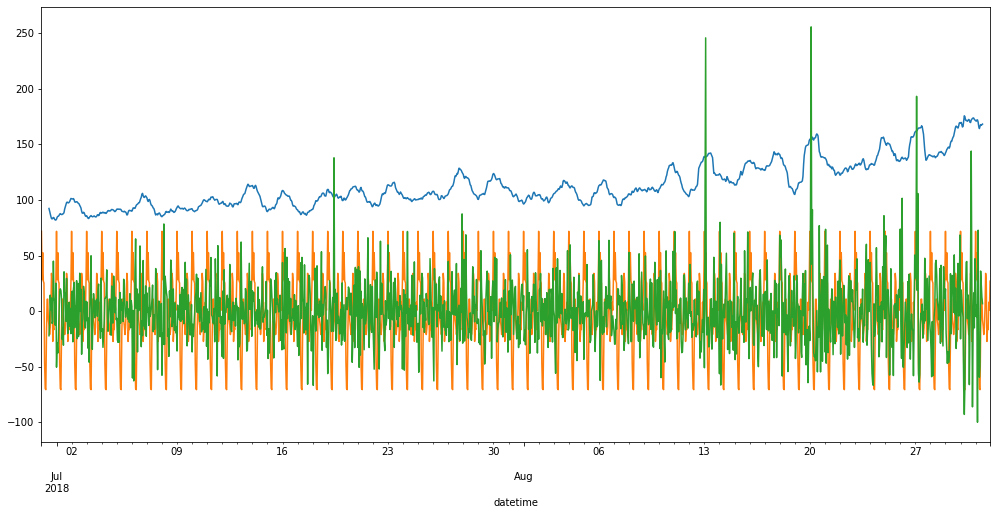

In [30]:
# тренды для последних 2-ух месяцев
decomposed_df = seasonal_decompose(df['2018-06-30':'2018-08-31'])
decomposed_df.trend.plot(figsize=figsize)
decomposed_df.seasonal.plot(figsize=figsize)
decomposed_df.resid.plot(figsize=figsize)

In [31]:
# Рассмотрим плавающее среднее для разных параметров
def rolling_mean(series, n):
    rolling_mean = series.rolling(window=n).mean()
    plt.figure(figsize=(16,5))
    plt.title("Скользящее среднее\n Размер окна = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

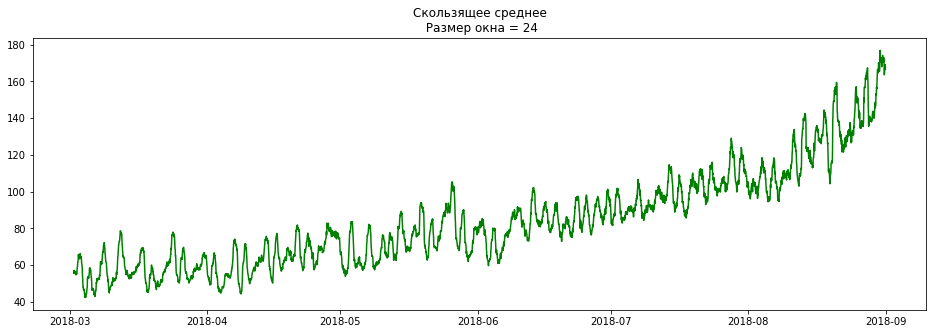

In [32]:
rolling_mean(df, 24)

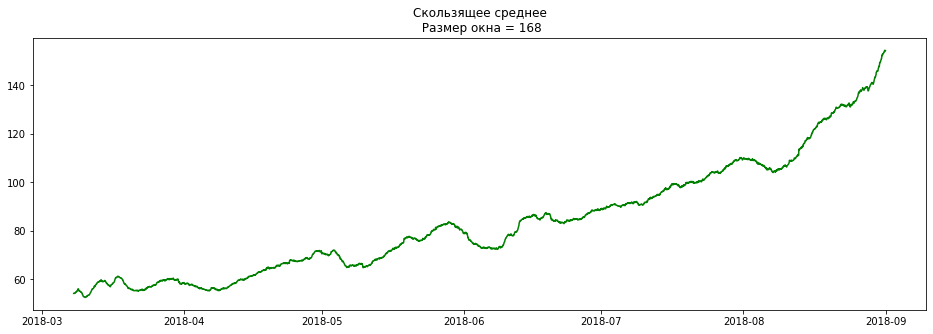

In [33]:
rolling_mean(df, 24*7)

In [34]:
def day(data, n):
    day = data.resample('1H').sum()
    day['std'] = day['num_orders'].rolling(window=n).std()
    day.plot(figsize=(16,5), title = 'График временного ряда')
    plt.show()

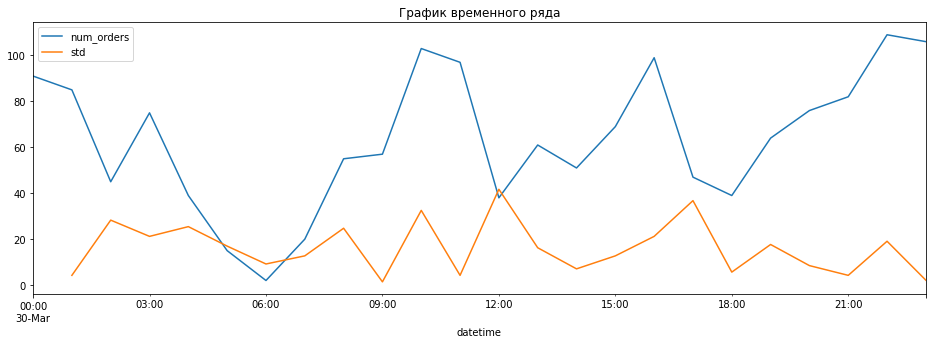

In [35]:
day(df['2018-03-30':'2018-03-30'], 2)

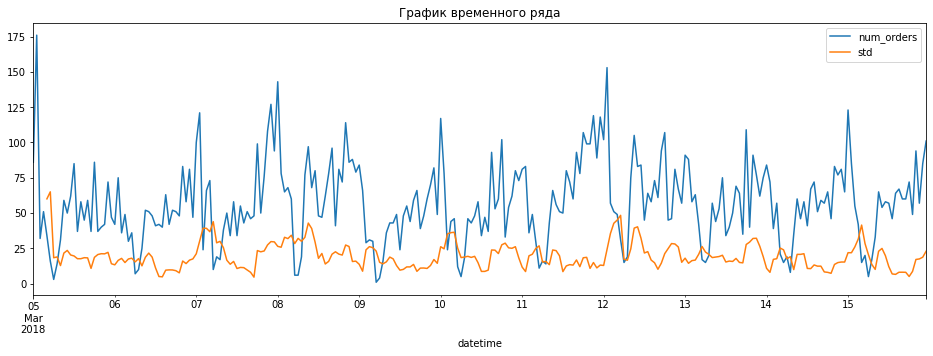

In [36]:
day(df['2018-03-05':'2018-03-15'], 5)

По итогу анализа данных четко видна сезонность в данных. Так же явно видно повышение спроса на такси от года к году.

## Обучение

In [37]:
def make_features(data, max_lag, rolling_mean_size):
#     data['year'] = data.index.year
#     data['month'] = data.index.month
#     data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
#     data['weekday'] = data.index.weekday
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    
    data = data.dropna()
    
    features = data.drop('num_orders', axis=1)
    target = data['num_orders']
    features_train, features_test, target_train, target_test = train_test_split(features,  target,
                                                                                  shuffle=False, test_size=0.1,
                                                                               random_state=12345)
    
    return features, target, data, features_train, features_test, target_train, target_test

In [38]:
features, target, data, features_train, features_test, target_train, target_test = make_features(df, 100, 5)

In [45]:
%%time


model = LinearRegression()
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(model, features_train, target_train, cv=tscv, scoring='neg_mean_squared_error')
cv_RMSE_LR = (np.mean(cv_scores) * -1) ** 0.5
print('# Train for root_mean_squared_error')
print()
print('Mean RMSE from CV of LinearRegression =', cv_RMSE_LR)


# Train for root_mean_squared_error

Mean RMSE from CV of LinearRegression = 24.10929339280633
CPU times: user 664 ms, sys: 748 ms, total: 1.41 s
Wall time: 1.34 s


In [47]:
%%time


tscv = TimeSeriesSplit(n_splits=3)
gradient_model = GradientBoostingRegressor(random_state=12345)
scores = cross_val_score(gradient_model, features_train, target_train, cv=tscv, scoring='neg_mean_squared_error')
cv_RMSE_Gradient = np.sqrt(-scores.mean())
print('Mean RMSE from CV of GradientBoostingRegressor =', cv_RMSE_Gradient)


Mean RMSE from CV of GradientBoostingRegressor = 25.10368541016668
CPU times: user 8.32 s, sys: 89.8 ms, total: 8.41 s
Wall time: 8.41 s


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'>👍</font>

In [46]:
%%time

    
    
tscv = TimeSeriesSplit(n_splits=3)
for depth in range(1, 25):
    model_d = DecisionTreeRegressor(max_depth=depth, random_state=12345)  
    cv_scores = cross_val_score(model_d, features_train, target_train, cv=tscv, scoring='neg_mean_squared_error')
    cv_RMSE = (cv_scores.mean() * -1) ** 0.5
    print("max_depth =", depth, ": ", end='')
    print('RMSE:', cv_RMSE)
    

max_depth = 1 : RMSE: 36.97000359363491
max_depth = 2 : RMSE: 33.53084748918283
max_depth = 3 : RMSE: 32.1124170550396
max_depth = 4 : RMSE: 29.697509557301892
max_depth = 5 : RMSE: 29.780274898984896
max_depth = 6 : RMSE: 30.587176445392405
max_depth = 7 : RMSE: 33.84473621196514
max_depth = 8 : RMSE: 34.87667202007839
max_depth = 9 : RMSE: 35.1576182844647
max_depth = 10 : RMSE: 36.371119266804804
max_depth = 11 : RMSE: 35.91334153896907
max_depth = 12 : RMSE: 36.48459452406814
max_depth = 13 : RMSE: 36.442729054938106
max_depth = 14 : RMSE: 37.9609832723121
max_depth = 15 : RMSE: 36.25960574533369
max_depth = 16 : RMSE: 37.400010533368075
max_depth = 17 : RMSE: 36.551357700681265
max_depth = 18 : RMSE: 37.071114475317465
max_depth = 19 : RMSE: 37.420109225600555
max_depth = 20 : RMSE: 37.13564439780181
max_depth = 21 : RMSE: 36.51151088288376
max_depth = 22 : RMSE: 36.50502752585845
max_depth = 23 : RMSE: 37.634590578077976
max_depth = 24 : RMSE: 37.674641968338584
CPU times: user 7

Линейная регрессия и градиентный бустинг показали схожие результаты. Модель дерева в данном случае не подходит, ее улучшение результата слишком тесно связано с переобучением.

## Тестирование

In [26]:
%%time
model_L = LinearRegression().fit(features_train, target_train)
model_L_predictions = model_L.predict(features_test)
print('RMSE:', mean_squared_error(target_test, model_L_predictions)**0.5)

RMSE: 40.12172459187783
CPU times: user 60.2 ms, sys: 48.7 ms, total: 109 ms
Wall time: 31.2 ms


In [27]:
%%time
gradient_model = GradientBoostingRegressor(random_state=12345).fit(features_train, target_train)
gradient_model_predictions = gradient_model.predict(features_test)
print('RMSE:', mean_squared_error(target_test, gradient_model_predictions)**0.5)

RMSE: 41.18446229192119
CPU times: user 5.68 s, sys: 11.5 ms, total: 5.69 s
Wall time: 5.69 s


In [24]:
# %%time
# # Дерево
# for depth in range(1, 25):
#     model_d = DecisionTreeRegressor(max_depth=depth, random_state=12345)  
#     model_d.fit(features_train, target_train)
#     predictions_valid = model_d.predict(features_test)
#     print("max_depth =", depth, ": ", end='')
#     print('RMSE:', mean_squared_error(target_test, predictions_valid)**0.5)

Было проведено исследование данных о заказах такси. Первоначальный анализ выявил сезонные компоненты в данных, на основе чего были добавлены параметры в данные: года, месяца, дни, дни недели, выходные, часы. После разбивки данных на обучающую и тестовую выборку были проанализированы 3 модели - линейная, градиентный бустинг и дерево. Дерево было определено как неподходящее для данного исследования (так же дало неприемлимый результат на тестовой выборке даже при разных гиперпараметрах). Модели градиентоного бустинга и линейная дали очень схожие результаты. Таким образом для предсказания количетсва заказов на следующий час подойдет любая из них (главным параметром тут может скорее служить время работы модели и размер датасета). 